In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Environment: missingness and past-only windows

**Beginner route:** read the [case lesson](../lessons/co2.md) and [dataset card](../cards/co2.md). Predict each result before executing.

Source: [Keeling and Whorf (2004), atmospheric CO2 series, CDIAC; historical statsmodels snapshot.](https://www.statsmodels.org/stable/datasets/generated/co2.html). Snapshot obtained by offline export from statsmodels 0.14.6. Numerical results below are our computations, not source claims.

This fixed test partition is a teaching demonstration, not an untouched future benchmark.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss, mean_absolute_error, mean_squared_error, roc_auc_score, confusion_matrix
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/shape_lab").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from shape_lab.industries import *
from shape_lab.persistence import rips_filtration, persistent_homology, diagram
CASE = "co2"
OUT = ROOT / "reports/v6/industries" / CASE
OUT.mkdir(parents=True, exist_ok=True)
SEED = 20260920

def write_json(name, value):
    def convert(x):
        if isinstance(x, np.ndarray): return x.tolist()
        if isinstance(x, np.generic): return x.item()
        raise TypeError(type(x).__name__)
    (OUT / name).write_text(json.dumps(value, indent=2, default=convert, allow_nan=False))

def plot_done(name):
    plt.tight_layout()
    plt.savefig(OUT / (name + ".png"), dpi=125)
    plt.show()

def regression_metrics(y, pred):
    return {"mae":float(mean_absolute_error(y,pred)),"rmse":float(mean_squared_error(y,pred)**.5)}

def class_metrics(y, pred):
    return {"accuracy":float(accuracy_score(y,pred)),"balanced_accuracy":float(balanced_accuracy_score(y,pred))}

def stratified_split(y):
    index=np.arange(len(y))
    train, other=train_test_split(index,test_size=.4,random_state=SEED,stratify=y)
    val,test=train_test_split(other,test_size=.5,random_state=SEED,stratify=y[other])
    return {"train":np.sort(train),"validation":np.sort(val),"test":np.sort(test)}

def save_split(split, ids):
    frames=[pd.DataFrame({"example_index":v,"source_id":np.asarray(ids)[v],"partition":k}) for k,v in split.items()]
    pd.concat(frames,ignore_index=True).to_csv(OUT / "split.csv",index=False)

def topology_report(points, name):
    bars=persistent_homology(rips_filtration(points,max_homology=1),max_dim=1)
    finite=[{"dimension":b.dim,"birth":b.birth,"death":b.death} for b in bars if np.isfinite(b.death)]
    write_json(name+".json",{"points":len(points),"coefficient_field":2,"edge_convention":"distance <= epsilon","finite_bars":finite,"essential_h0":1,"role":"exploratory descriptor, not significance"})
    plt.figure(figsize=(7,4))
    for dim in (0,1):
        a=diagram(bars,dim,finite_only=True)
        if len(a): plt.scatter(a[:,0],a[:,1],label="H"+str(dim),s=22)
    plt.xlabel("Birth (declared metric units)");plt.ylabel("Death (same units)");plt.title(name.replace('_',' '));plt.legend()
    plot_done(name)
    return finite

df, meta = load_dataset(CASE)
print(meta["title"])
print("Shape:",df.shape,"; snapshot SHA-256:",meta["data_sha256"])
print("Observation unit:",meta["observation_unit"])
display(df.head())
write_json("protocol.json",{"dataset":CASE,"seed":SEED,"data_sha256":meta["data_sha256"],"code_sha256":hashlib.sha256((ROOT/"src/shape_lab/industries.py").read_bytes()).hexdigest(),"data_kind":"observed","evaluation":"fixed teaching experiment; displayed test outcomes are now exposed","external_validation":False})


Missingness, past-only windows and seasonal shape
Shape: (2284, 3) ; snapshot SHA-256: b67fef114ef5c027ad8b5e0aeae76525f218184df64bbf289a7d299a13c14277
Observation unit: One weekly date slot, possibly missing a CO2 observation.


,row_id,date,co2
0,0,1958-03-29,316.1
1,1,1958-04-05,317.3
2,2,1958-04-12,317.6
3,3,1958-04-19,317.5
4,4,1958-04-26,316.4


## 1. A blank observation is not zero

The archive has 2,284 weekly date slots but only 2,225 measurements. Fifty-nine missing values remain missing. Dropping them and treating adjacent remaining rows as adjacent weeks would change the time axis. We create source-traceable windows and reject windows that cross a missing measurement or a time gap.

In [3]:
dates=pd.to_datetime(df.date);days=(dates-dates.iloc[0]).dt.days.to_numpy();values=df.co2.to_numpy(float)
assert np.isnan(values).sum()==59
batch=past_windows(values,days,length=12,horizon=1,expected_step=7)
raw=ordered_split(days);split=assign_windows(batch,raw)
save_split(split,batch.target)
write_json("window_audit.json",{"raw_slots":len(df),"observed":int(np.isfinite(values).sum()),"missing":int(np.isnan(values).sum()),"valid_windows":len(batch.y),"partition_windows":{k:len(v) for k,v in split.items()},"strict_boundary_policy":True})
print(json.loads((OUT/"window_audit.json").read_text()))

{'raw_slots': 2284, 'observed': 2225, 'missing': 59, 'valid_windows': 2022, 'partition_windows': {'train': 1124, 'validation': 432, 'test': 445}, 'strict_boundary_policy': True}


## 2. Define exactly what is being forecast

Each example uses twelve observed past weeks to predict one week ahead. During test evaluation later test predictions may use earlier **observed** test-period readings. This is rolling one-step prediction, not a free-running forecast of the entire future.

Our strict support split drops boundary windows instead of borrowing history across partitions; it is conservative and explicitly different from a less restrictive operational evaluation.

In [4]:
scale=TrainScaler.fit(batch.x[split["train"]]);z=scale.transform(batch.x)
model=Ridge(alpha=1).fit(z[split["train"]],batch.y[split["train"]]);results={}
for k in ("validation","test"):
    ix=split[k];pred=model.predict(z[ix]);last=batch.x[ix,-1]
    results[k]={"ridge":regression_metrics(batch.y[ix],pred),"last_value":regression_metrics(batch.y[ix],last),"n":len(ix)}
    pd.DataFrame({"start_row":batch.start[ix],"last_feature_row":batch.end[ix],"target_row":batch.target[ix],"target_date":df.date.to_numpy()[batch.target[ix]],"observed":batch.y[ix],"ridge":pred,"last_value":last}).to_csv(OUT/(k+"_predictions.csv"),index=False)
write_json("results.json",results);print(results)
write_json("preprocessing.json",{"mean":scale.mean,"scale":scale.scale,"features":"12 observed weekly lags in chronological order","units":"ppmv","forecast_mode":"rolling one-step observed-history"})

{'validation': {'ridge': {'mae': 0.3741658983394172, 'rmse': 0.4677844961147414}, 'last_value': {'mae': 0.4180555555555548, 'rmse': 0.5185003303688358}, 'n': 432}, 'test': {'ridge': {'mae': 0.3659190237090925, 'rmse': 0.4745391438854755}, 'last_value': {'mae': 0.40404494382022477, 'rmse': 0.5134592967686957}, 'n': 445}}


## 3. Inspect trend, gaps, and a delay-space cloud

A delay vector turns a time interval into a point. A loop may reflect seasonal repetition. It is not proof that the scalar series uniquely reconstructs the atmosphere's physical state. The point-cloud sample below is training-only; no test labels decide which diagram to show.

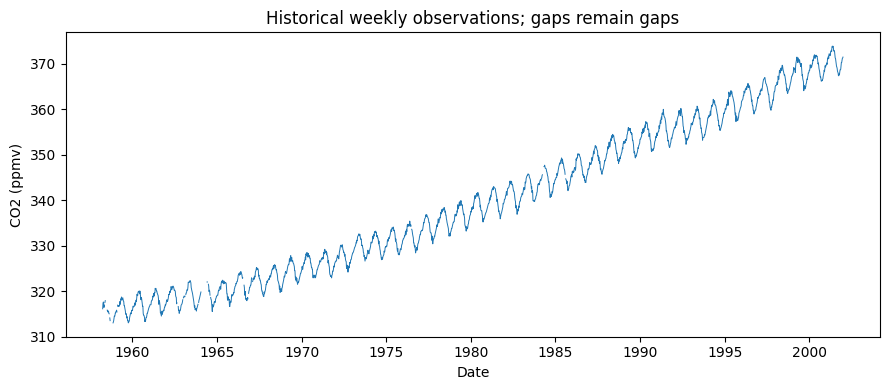

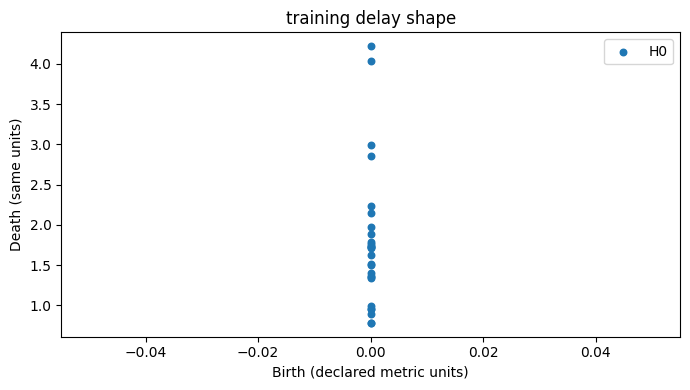

In [5]:
plt.figure(figsize=(9,4));plt.plot(dates,values,linewidth=.7);plt.xlabel("Date");plt.ylabel("CO2 (ppmv)");plt.title("Historical weekly observations; gaps remain gaps");plot_done("observations")
ix=np.random.default_rng(SEED).choice(split["train"],size=28,replace=False)
# Subtract each window's first value to inspect short-term shape, not long-term level.
centered=batch.x[ix]-batch.x[ix][:,[0]]
_ = topology_report(centered,"training_delay_shape")

## 4. Diagnose an invalid shortcut

Why is interpolation using readings on both sides of a future gap unavailable for an online forecast? Why should overlapping windows not be treated as independent patients? How would changing the forecast horizon alter the information set?

Further model development needs a new locked protocol; the displayed test results are already exposed. These are historical observations, not a statement of today's atmospheric concentration.

## Save your evidence

Create `my_work/industries/co2.md` with your prediction, actual result, explanation, one failed assumption and one claim the evidence does not justify. Use the separate learner notebook only after you understand the worked code. No notebook execution automatically marks your learning complete.